In [74]:
#! pip install pandas
#! pip install matplotlib
#! pip install imblearn
! pip install lightgbm


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.3 MB/s eta 0:00:00


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_classification
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score , confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from collections import Counter
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats


In [32]:
# Charger les données
data = pd.read_csv('bank.csv' , sep=';')


In [5]:
# Aperçu des données
print(data.info())
print(data.describe())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None
               age       balance          day     duration     campaign  \
count  4521.000000 

In [6]:
# Détection des valeurs manquantes
missing_values = data.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_values)

Valeurs manquantes par colonne :
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [7]:
# Vérification des doublons
duplicates = data.duplicated().sum()
print(f"Nombre de doublons : {duplicates}")

# Vérification des valeurs uniques dans les colonnes catégoriques
for col in data.select_dtypes(include='object').columns:
    print(f"Valeurs uniques dans la colonne '{col}' : {data[col].unique()}")

# Analyse des valeurs extrêmes dans les colonnes numériques
for col in data.select_dtypes(include='int64').columns:
    print(f"Résumé statistique de la colonne '{col}':\n{data[col].describe()}")


Nombre de doublons : 0
Valeurs uniques dans la colonne 'job' : ['unemployed' 'services' 'management' 'blue-collar' 'self-employed'
 'technician' 'entrepreneur' 'admin.' 'student' 'housemaid' 'retired'
 'unknown']
Valeurs uniques dans la colonne 'marital' : ['married' 'single' 'divorced']
Valeurs uniques dans la colonne 'education' : ['primary' 'secondary' 'tertiary' 'unknown']
Valeurs uniques dans la colonne 'default' : ['no' 'yes']
Valeurs uniques dans la colonne 'housing' : ['no' 'yes']
Valeurs uniques dans la colonne 'loan' : ['no' 'yes']
Valeurs uniques dans la colonne 'contact' : ['cellular' 'unknown' 'telephone']
Valeurs uniques dans la colonne 'month' : ['oct' 'may' 'apr' 'jun' 'feb' 'aug' 'jan' 'jul' 'nov' 'sep' 'mar' 'dec']
Valeurs uniques dans la colonne 'poutcome' : ['unknown' 'failure' 'other' 'success']
Valeurs uniques dans la colonne 'y' : ['no' 'yes']
Résumé statistique de la colonne 'age':
count    4521.000000
mean       41.170095
std        10.576211
min        19.0000

In [9]:
# Comptage des valeurs 'unknown' dans les colonnes catégoriques
for col in ['job', 'education', 'poutcome']:
    print(f"Valeurs 'unknown' dans {col}: {data[col].value_counts()['unknown']}")


Valeurs 'unknown' dans job: 38
Valeurs 'unknown' dans education: 187
Valeurs 'unknown' dans poutcome: 3705


y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64
Répartition des classes :
y
no     4000
yes     521
Name: count, dtype: int64


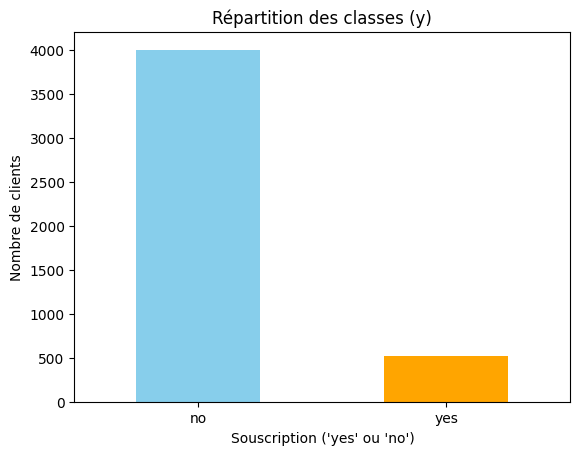

In [12]:
# Vérification de la répartition des classes
class_distribution = data['y'].value_counts()
# Distribution des classes cibles
print(data['y'].value_counts(normalize=True))

print("Répartition des classes :")
print(class_distribution)
class_distribution.plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Répartition des classes (y)")
plt.xlabel("Souscription ('yes' ou 'no')")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.show()

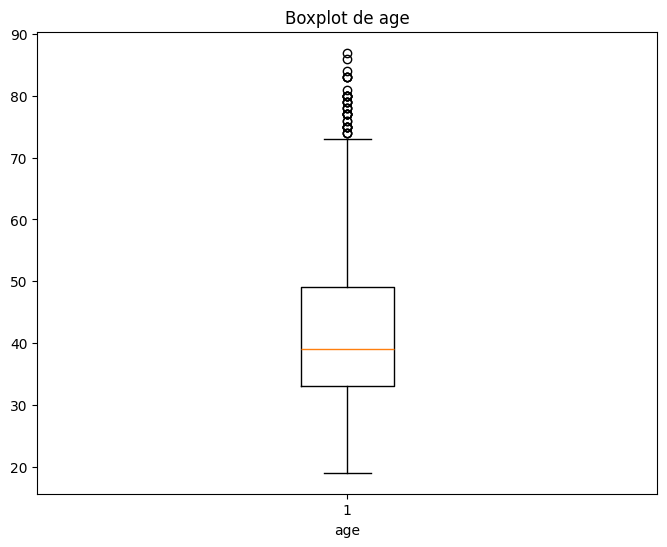

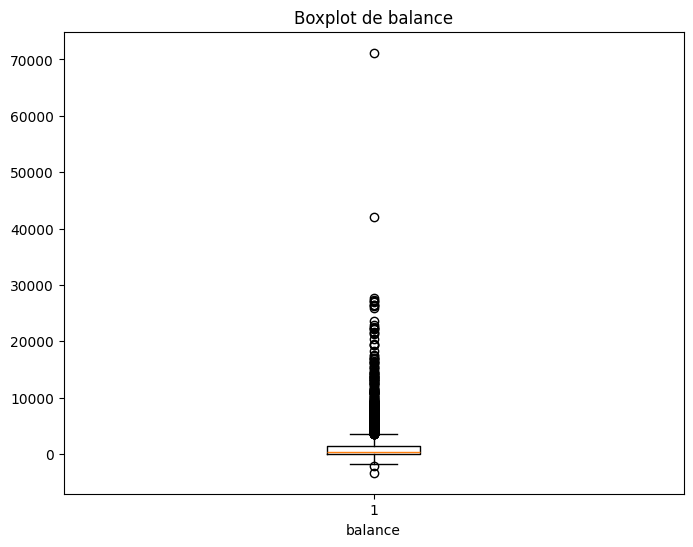

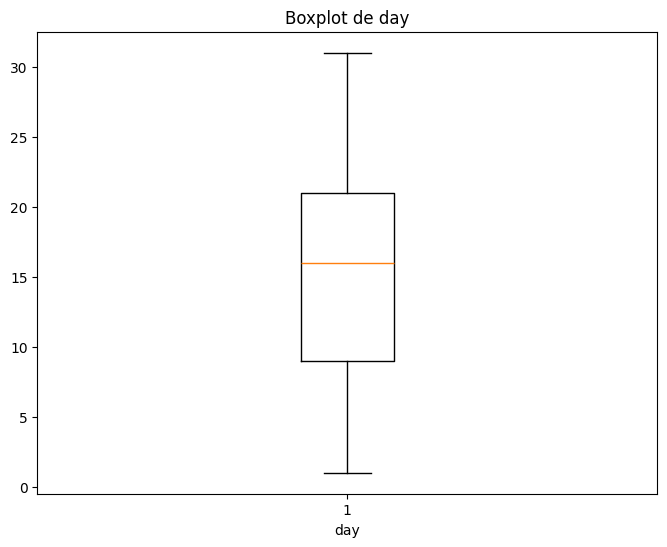

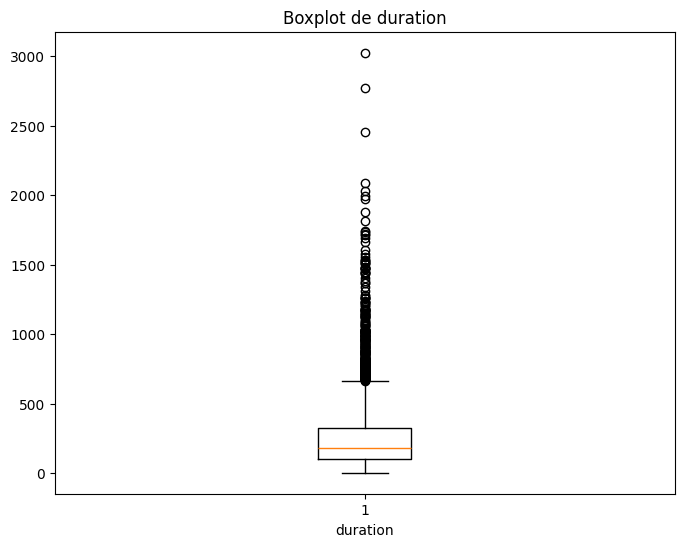

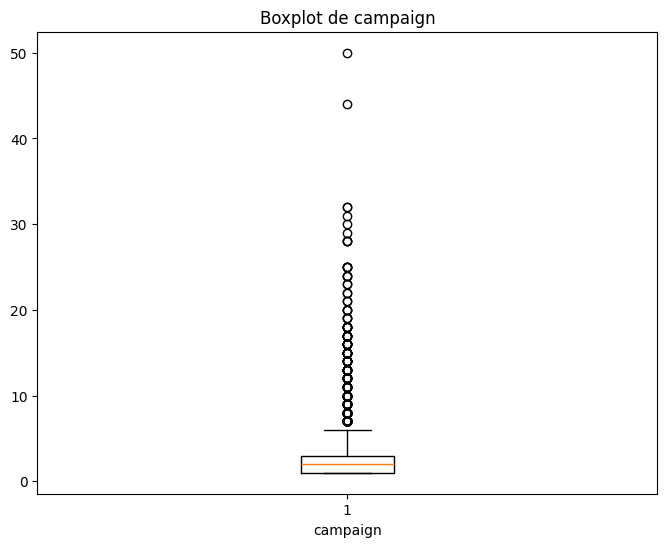

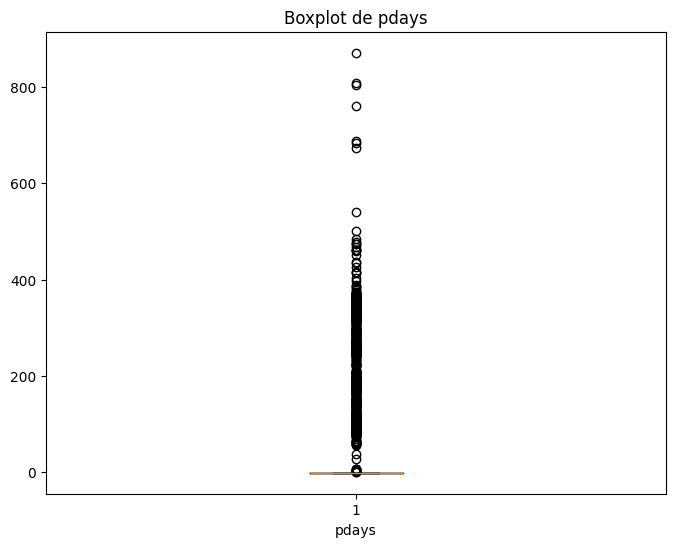

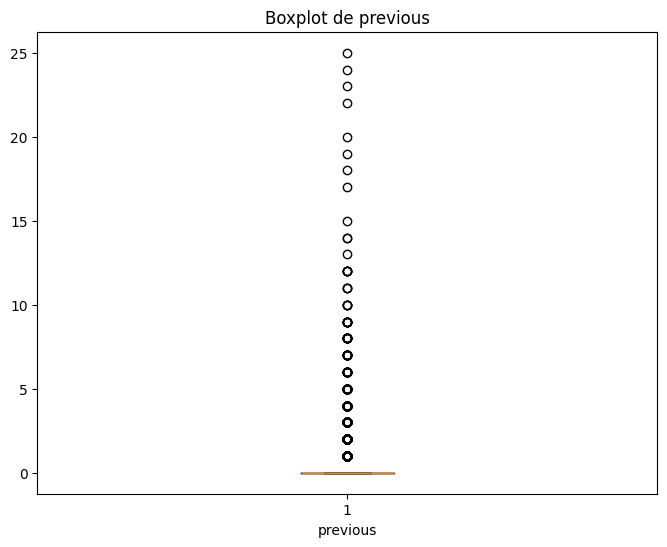

In [45]:
bank_columns_num = data.select_dtypes(include=['float', 'int']).columns
for column in bank_columns_num:
    plt.figure(figsize=(8, 6))
    plt.boxplot(data[column].dropna(), vert=True)
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.show()


Dés lors, nous constatons que certaines distributions ne sont pas "symétriques" et peuvent influer des biais dans les algorithmes.

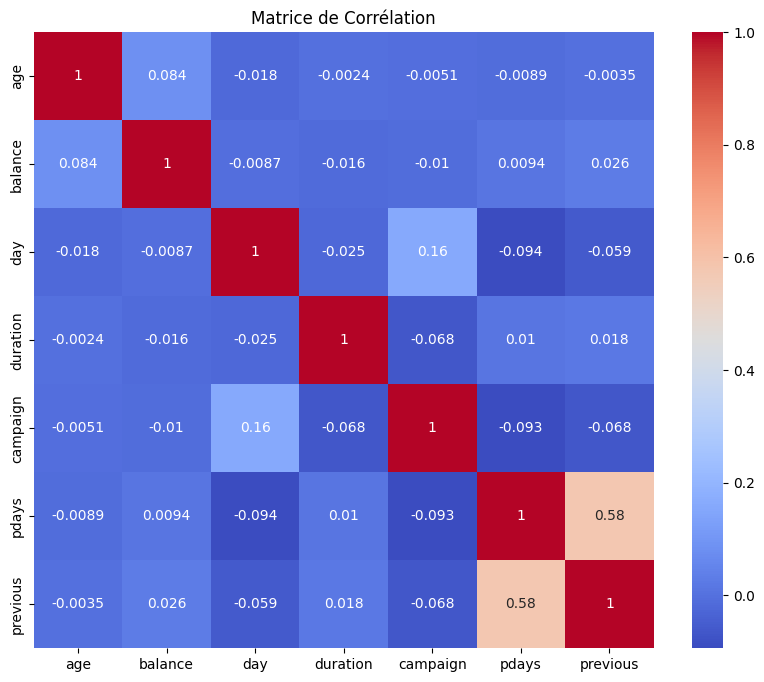

In [17]:
#Matrice de corrélation entre variables numériques
# Exclure les colonnes non numériques
numeric_data = data.select_dtypes(include=['number'])

# Calculer la matrice de corrélation
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation')
plt.show()

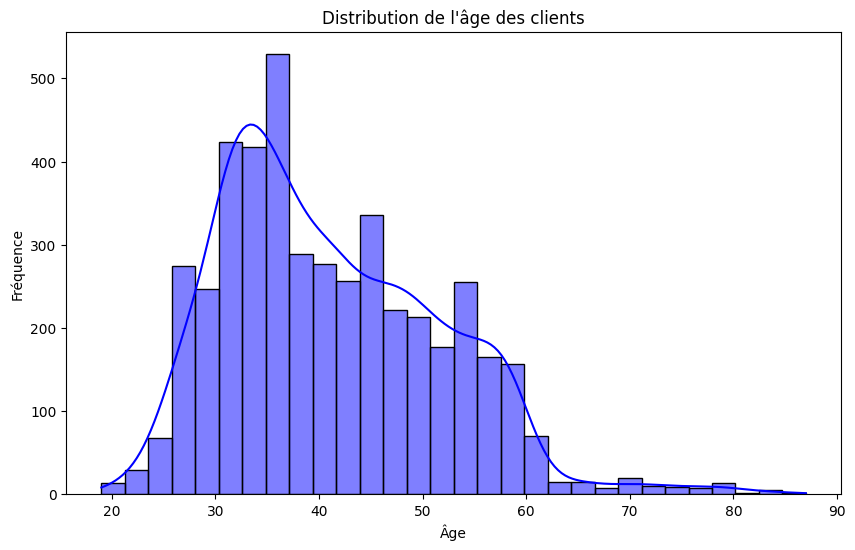

In [47]:
#Distribution de l'âge (age) :
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='age', bins=30, kde=True, color='blue')
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()


C:\Users\ayaam\AppData\Local\Temp\ipykernel_36156\484978803.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='y_yes', y='balance', palette='coolwarm')


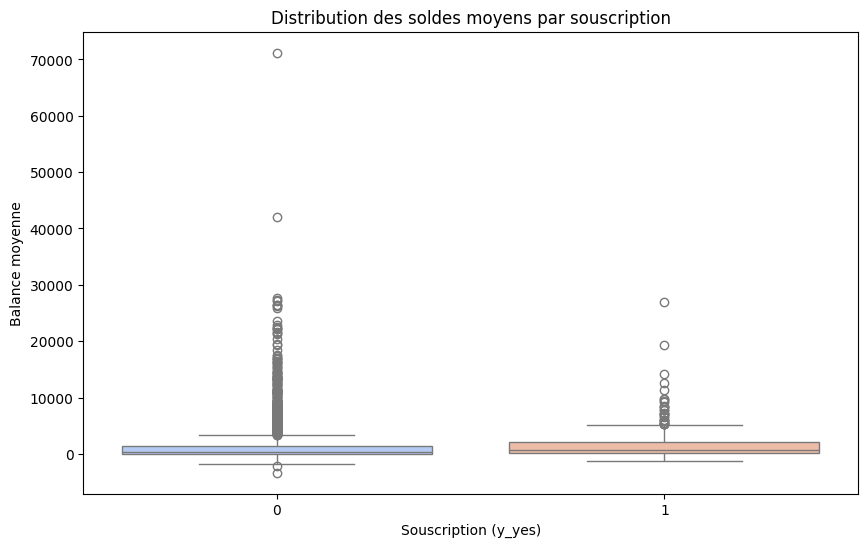

In [ ]:
#Répartition des soldes moyens (balance) :
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='y', y='balance', palette='coolwarm')
plt.title("Distribution des soldes moyens par souscription")
plt.xlabel("Souscription (y_yes)")
plt.ylabel("Balance moyenne")
plt.show()


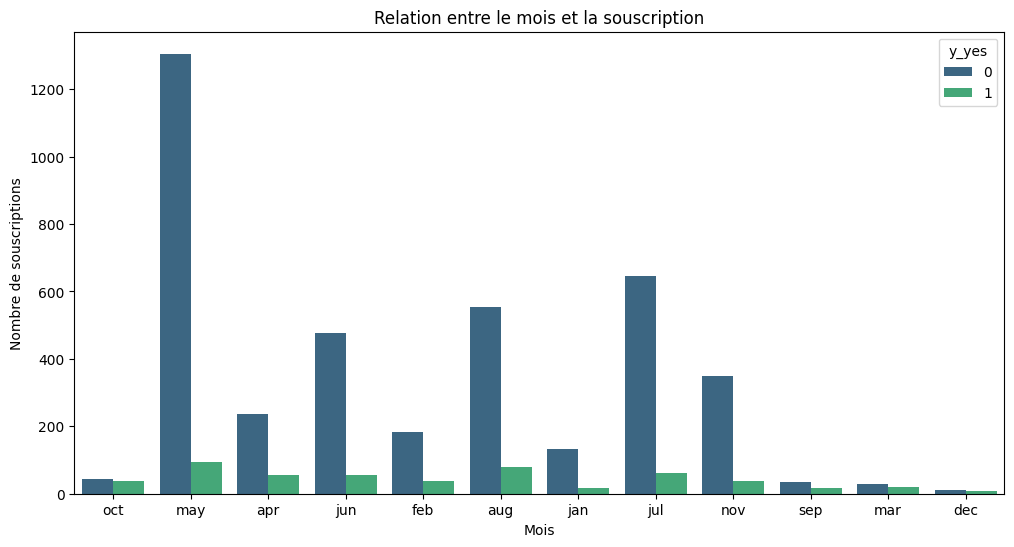

In [ ]:
#Relation entre le mois et la souscription :
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='month', hue='y', palette='viridis')
plt.title("Relation entre le mois et la souscription")
plt.xlabel("Mois")
plt.ylabel("Nombre de souscriptions")
plt.show()


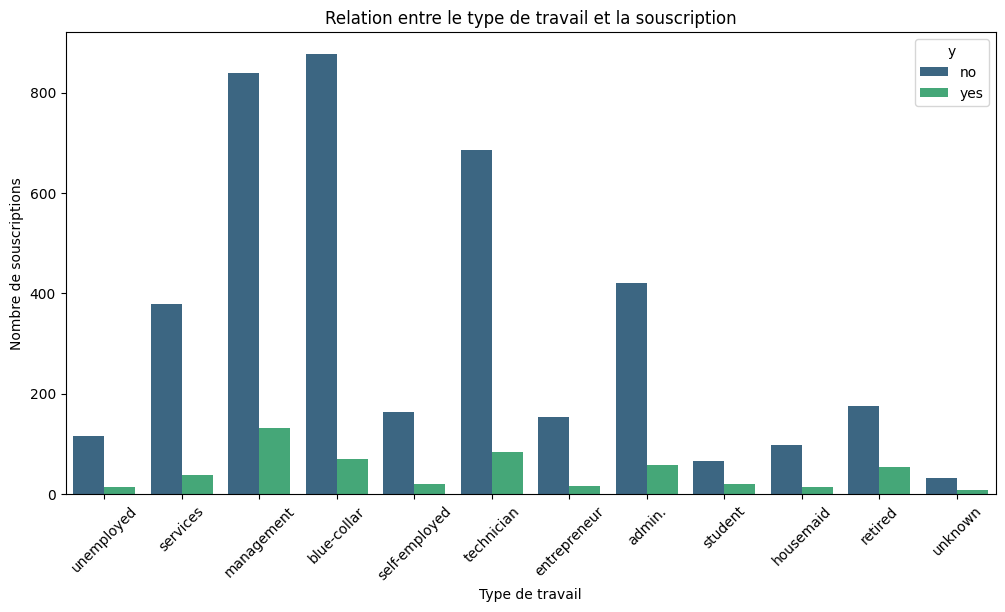

In [58]:
# relation entre job et souscription 
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='job', hue='y', palette='viridis')
plt.title("Relation entre le type de travail et la souscription")
plt.xlabel("Type de travail")
plt.ylabel("Nombre de souscriptions")
plt.xticks(rotation=45)
plt.show()


# predire Y

## random forest 

In [61]:
data_coded=data.copy()
# 1. Label Encoding pour les variables ordinales (si applicable)
label_encoder = LabelEncoder()

# Liste des variables ordinales
# On applique le LabelEncoder uniquement aux variables ordinales
data_coded['education'] = label_encoder.fit_transform(data_coded['education'])  # 'primary' -> 0, 'secondary' -> 1, 'tertiary' -> 2
data_coded['marital'] = label_encoder.fit_transform(data_coded['marital']) 
data_coded['default'] = label_encoder.fit_transform(data_coded['default']) 
data_coded['housing'] = label_encoder.fit_transform(data_coded['housing']) 
data_coded['loan'] = label_encoder.fit_transform(data_coded['loan'])
data_coded['y'] = label_encoder.fit_transform(data_coded['y'])  
data_coded = pd.get_dummies(data_coded, columns=['job', 'month', 'contact', 'poutcome'], drop_first=True)

# Vérification des résultats
print(data_coded.head())

   age  marital  education  default  balance  housing  loan  day  duration  \
0   30        1          0        0     1787        0     0   19        79   
1   33        1          1        0     4789        1     1   11       220   
2   35        2          2        0     1350        1     0   16       185   
3   30        1          2        0     1476        1     1    3       199   
4   59        1          1        0        0        1     0    5       226   

   campaign  ...  month_mar  month_may  month_nov  month_oct  month_sep  \
0         1  ...      False      False      False       True      False   
1         1  ...      False       True      False      False      False   
2         1  ...      False      False      False      False      False   
3         4  ...      False      False      False      False      False   
4         1  ...      False       True      False      False      False   

   contact_telephone  contact_unknown  poutcome_other  poutcome_success  \
0    

# sans gestion du déséquilibre

In [62]:
# Séparation des données
X = data_coded.drop('y', axis=1)
y = data_coded['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entraînement et évaluation
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Résultats
print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1205
           1       1.00      1.00      1.00       152

    accuracy                           1.00      1357
   macro avg       1.00      1.00      1.00      1357
weighted avg       1.00      1.00      1.00      1357

ROC-AUC : 1.0


# Suréchantillonnage de la classe minoritaire (SMOTE)

In [71]:
# Appliquer SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Vérification des nouvelles distributions
print("Distribution après SMOTE :", Counter(y_resampled))


Distribution après SMOTE : Counter({0: 2795, 1: 2795})


In [73]:
model = RandomForestClassifier(random_state=42)
model.fit(X_resampled, y_resampled)

# Évaluation sur l'ensemble de test
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1205
           1       1.00      1.00      1.00       152

    accuracy                           1.00      1357
   macro avg       1.00      1.00      1.00      1357
weighted avg       1.00      1.00      1.00      1357



## avec K-Fold cross validation : 

In [ ]:
# Exemple de données

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# Modèle
model = RandomForestClassifier(random_state=42)

# Cross-validation
acc_Scores=cross_val_score(model, X, y, cv=5, scoring='accuracy')
F1_Scores=cross_val_score(model, X, y, cv=5, scoring='f1')

print("F1 Scores par fold :", F1_Scores)
print("F1 Score moyen :", F1_Scores.mean())

F1 Scores par fold : [0.92857143 0.90452261 0.89361702 0.90640394 0.85427136]
F1 Score moyen : 0.897477272116794


## gradient Boosting 

In [ ]:

# Création du modèle LightGBM
lgb_model = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
lgb_model.fit(X_train, y_train)

# Prédictions et évaluation
y_pred = lgb_model.predict(X_test)
print(classification_report(y_test, y_pred))


[LightGBM] [Info] Number of positive: 369, number of negative: 2795
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 895
[LightGBM] [Info] Number of data points in the train set: 3164, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

## logistic regression 

In [91]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# Création d'un pipeline pour inclure la normalisation et le modèle
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

# Définition des folds pour la validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5 folds stratifiés

# Calcul du F1 Score pour chaque fold
f1_scores = cross_val_score(
    pipeline, X_train, y_train, cv=cv, scoring='f1'
)

# Calcul du ROC AUC pour chaque fold
roc_auc_scores = cross_val_score(
    pipeline, X_train, y_train, cv=cv, scoring='roc_auc'
)

# Affichage des résultats de validation croisée
print(f"F1 Scores par fold : {f1_scores}")
print(f"F1 Score moyen : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"\nROC AUC Scores par fold : {roc_auc_scores}")
print(f"ROC AUC Score moyen : {roc_auc_scores.mean():.4f} ± {roc_auc_scores.std():.4f}")

# Ajustement final sur l'ensemble d'entraînement complet
pipeline.fit(X_train, y_train)

# Évaluation finale sur l'ensemble de test
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Classification Report
print("\nClassification Report :")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred))

# Score AUC-ROC sur l'ensemble de test
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC AUC Score sur l'ensemble de test : {roc_auc:.4f}")

# F1 Score sur l'ensemble de test
f1_test = f1_score(y_test, y_pred)
print(f"F1 Score sur l'ensemble de test : {f1_test:.4f}")

# Interprétation des coefficients
model = pipeline.named_steps['logisticregression']  # Récupérer le modèle
coefficients = pd.DataFrame(model.coef_[0], X.columns, columns=['Coefficient'])
print("\nCoefficients du modèle de régression logistique :")
print(coefficients)


F1 Scores par fold : [1. 1. 1. 1. 1.]
F1 Score moyen : 1.0000 ± 0.0000

ROC AUC Scores par fold : [1. 1. 1. 1. 1.]
ROC AUC Score moyen : 1.0000 ± 0.0000

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1205
           1       1.00      1.00      1.00       152

    accuracy                           1.00      1357
   macro avg       1.00      1.00      1.00      1357
weighted avg       1.00      1.00      1.00      1357


Confusion Matrix :
[[1205    0]
 [   0  152]]

ROC AUC Score sur l'ensemble de test : 1.0000
F1 Score sur l'ensemble de test : 1.0000

Coefficients du modèle de régression logistique :
                   Coefficient
age                  -0.001241
marital               0.007268
education             0.029188
default               0.036579
balance              -0.021309
housing              -0.062720
loan                 -0.086884
day                   0.008051
duration              0.478319

## ANNOVA

In [86]:
# Effectuer un ANOVA
f_stat, p_value = stats.f_oneway(data[data['education'] == 'primary']['balance'],
                                  data[data['education'] == 'secondary']['balance'],
                                  data[data['education'] == 'tertiary']['balance'])

# Afficher les résultats
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")


F-statistic: 15.83370460126531
P-value: 1.4077558848924147e-07
